In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('combined_data.csv', sep=';')

In [16]:
df ['date'] = pd.to_datetime(df ['date'])
df  = df [df ['date'].dt.year > 2017]


In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 3921 entries, 291 to 13457
Data columns (total 31 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   name     3921 non-null   str           
 1   Head     3921 non-null   float64       
 2   year     3921 non-null   int64         
 3   month    3921 non-null   int64         
 4   x        3574 non-null   float64       
 5   y        3574 non-null   float64       
 6   z        3574 non-null   float64       
 7   depth    3574 non-null   float64       
 8   top      3323 non-null   float64       
 9   top8     3059 non-null   float64       
 10  bot      3282 non-null   float64       
 11  M        3282 non-null   float64       
 12  m        2737 non-null   float64       
 13  Km       1874 non-null   float64       
 14  a        1320 non-null   float64       
 15  region   3921 non-null   str           
 16  T_mean   3921 non-null   float64       
 17  T_min    3921 non-null   float64       
 18  T

In [18]:
# 1. Предобработка данных

# Заполняем пропуски для числовых столбцов
numeric_columns = ['T_mean', 'T_min', 'T_max', 'Po_mean', 'Po_min',
                  'Po_max', 'U_mean', 'U_min', 'U_max', 'sum_RRR',
                  'z', 'Head', 'depth', 'top', 'top8', 'bot', 'M', 'm', 'Km', 'a']

for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Кодируем категориальные переменные
categorical_columns = ['name', 'region']
label_encoders = {}

for col in categorical_columns:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Преобразуем даты в числовые признаки
if 'date_y' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofyear'] = df['date'].dt.dayofyear


In [19]:
# 2. Выбор признаков для модели
feature_columns = [
    'month', 'T_mean', 'T_min', 'T_max', 'Po_mean', 'Po_min', 'Po_max',
    'U_mean', 'U_min', 'U_max', 'sum_RRR', 'z', 'depth', 'top', 'top8',
    'bot', 'M', 'm', 'Km', 'a', 'year', 'day', 'dayofyear',
    'name_encoded', 'region_encoded'
]

# Удаляем столбцы, которых нет в данных
feature_columns = [col for col in feature_columns if col in df.columns]

X = df[feature_columns]
y = df['Head']  # целевая переменная


In [27]:
X.info()

<class 'pandas.DataFrame'>
Index: 3921 entries, 291 to 13457
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           3921 non-null   int64  
 1   T_mean          3921 non-null   float64
 2   T_min           3921 non-null   float64
 3   T_max           3921 non-null   float64
 4   Po_mean         3921 non-null   float64
 5   Po_min          3921 non-null   float64
 6   Po_max          3921 non-null   float64
 7   U_mean          3921 non-null   float64
 8   U_min           3921 non-null   float64
 9   U_max           3921 non-null   float64
 10  sum_RRR         3921 non-null   float64
 11  z               3921 non-null   float64
 12  depth           3921 non-null   float64
 13  top             3921 non-null   float64
 14  top8            3921 non-null   float64
 15  bot             3921 non-null   float64
 16  M               3921 non-null   float64
 17  m               3921 non-null   float64
 18  K

In [20]:
# 3. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Обучение модели Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,      # количество деревьев
    max_depth=10,       # максимальная глубина деревьев
    min_samples_split=5, # минимальное количество образцов для разделения узла
    min_samples_leaf=2,  # минимальное количество образцов в листе
    random_state=42,
    n_jobs=-1            # использовать все ядра процессора
)

In [21]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# 5. Предсказание
y_pred = rf_model.predict(X_test)

# 6. Оценка качества модели
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"R² (коэффициент детерминации): {r2:.3f}")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

R² (коэффициент детерминации): 0.968
MAE:  5.61
RMSE: 9.47
MAPE: 3.53%


In [23]:
# 7. Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажность признаков:")
print(feature_importance.head(10))



Важность признаков:
           feature  importance
20            year    0.285640
22  region_encoded    0.256193
11               z    0.198918
12           depth    0.114380
16               M    0.028473
21    name_encoded    0.018640
13             top    0.018237
14            top8    0.016453
15             bot    0.012357
0            month    0.011223


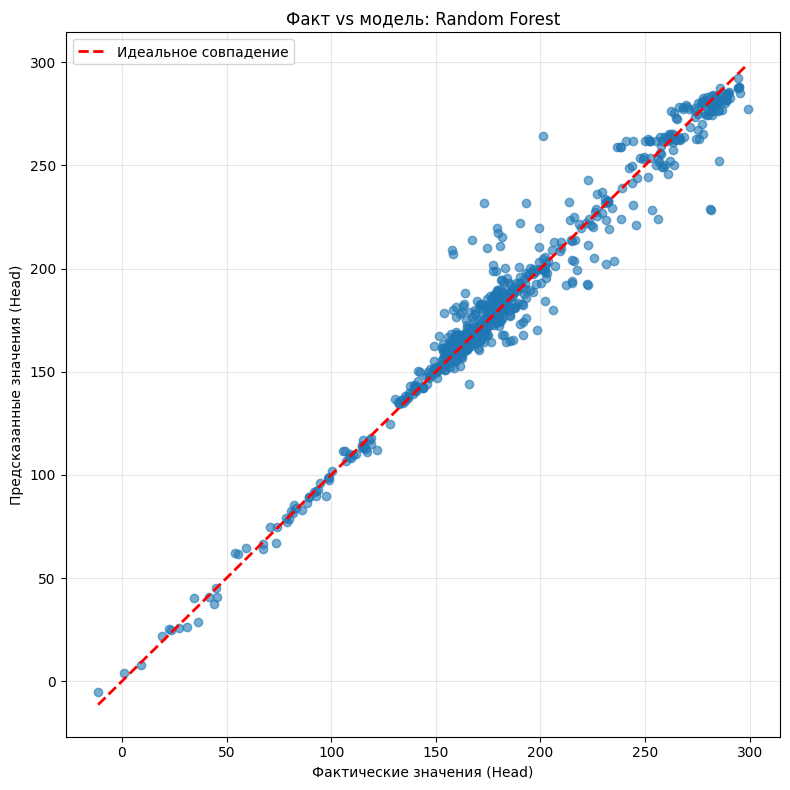

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.plot(y_test, y_pred, 'o', alpha=0.6, markersize=6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Идеальное совпадение')

plt.xlabel('Фактические значения (Head)')
plt.ylabel('Предсказанные значения (Head)')
plt.title('Факт vs модель: Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:

# 8. Создание итоговой таблицы с результатами
results_df = df.loc[X_test.index].copy()
results_df['Predicted_Head'] = y_pred
results_df['Error'] = results_df['Head'] - results_df['Predicted_Head']
results_df['Absolute_Error'] = np.abs(results_df['Error'])
results_df['Percentage_Error'] = np.abs(results_df['Error'] / results_df['Head']) * 100

# Выводим итоговую таблицу с основными столбцами
output_columns = [
    'month', 'T_mean', 'T_min', 'T_max', 'Po_mean', 'Po_min', 'Po_max',
    'U_mean', 'U_min', 'U_max', 'sum_RRR', 'date', 'name', 'z', 'date_y',
    'h', 'Head', 'Predicted_Head', 'Error', 'Absolute_Error', 'Percentage_Error'
]

output_columns = [col for col in output_columns if col in results_df.columns]
print("\nИтоговая таблица с предсказаниями (первые 10 строк):")
print(results_df[output_columns].head(10).round(2))



Итоговая таблица с предсказаниями (первые 10 строк):
       month  T_mean  T_min  T_max  Po_mean  Po_min  Po_max  U_mean  U_min  \
63         6   13.79    4.7   22.8   727.73   714.3   739.1   72.71   31.0   
11026      1  -34.21  -44.1  -15.4   727.73   714.3   739.1   72.71   31.0   
7976       7   19.94    9.0   34.2   722.07   713.5   728.9   64.17   25.0   
304        2  -20.17  -45.0   -5.5   730.31   716.6   743.8   79.83   56.0   
10114     12  -39.24  -45.8  -31.6   727.73   714.3   739.1   72.71   31.0   
8523       4   -6.28  -14.7    0.5   727.73   714.3   739.1   72.71   31.0   
9597       6   16.58    5.4   23.9   727.73   714.3   739.1   72.71   31.0   
4238      12  -31.82  -43.0  -11.7   733.07   712.3   746.2   73.07   59.0   
2109      10   -3.62  -25.2   14.1   726.06   710.4   736.4   82.59   37.0   
12356      2  -23.65  -37.4  -12.7   727.73   714.3   739.1   72.71   31.0   

       U_max  sum_RRR        date  name      z    Head  Predicted_Head  Error  \
63    